In [30]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import random
import os

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [31]:
df = pd.read_csv('Meshva_dataset.csv')
print(f"Columns: {df.columns.tolist()}")
TARGET = 'generated_power_kw'
DROP_COLS = [
    'wind_speed_80_m_above_gnd',
    'wind_direction_80_m_above_gnd',
    'wind_speed_900_mb',
    'wind_direction_900_mb',
    'wind_gust_10_m_above_gnd'
]
df = df.drop(columns=DROP_COLS)

df["cos_zenith"] = np.cos(np.radians(df["zenith"])).clip(lower=0)
df["cos_aoi"]    = np.cos(np.radians(df["angle_of_incidence"])).clip(lower=0)
df["irr_proj"]   = df["shortwave_radiation_backwards_sfc"] * df["cos_aoi"]

y = df[TARGET]
X = df.drop(columns=[TARGET])

Columns: ['temperature_2_m_above_gnd', 'relative_humidity_2_m_above_gnd', 'mean_sea_level_pressure_MSL', 'total_precipitation_sfc', 'snowfall_amount_sfc', 'total_cloud_cover_sfc', 'high_cloud_cover_high_cld_lay', 'medium_cloud_cover_mid_cld_lay', 'low_cloud_cover_low_cld_lay', 'shortwave_radiation_backwards_sfc', 'wind_speed_10_m_above_gnd', 'wind_direction_10_m_above_gnd', 'wind_speed_80_m_above_gnd', 'wind_direction_80_m_above_gnd', 'wind_speed_900_mb', 'wind_direction_900_mb', 'wind_gust_10_m_above_gnd', 'angle_of_incidence', 'zenith', 'azimuth', 'generated_power_kw']


In [32]:
# --- CHRONOLOGICAL SPLIT (no shuffle) ---
# Rows are in time order (each ~9-row block is one day's daytime hours).
# Train on the earliest 80%, test on the most recent 20% = "train on past, predict future".
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train rows: {len(X_train)} | Test rows: {len(X_test)}")

# Scaler is fit ONLY on training data (no peeking at the test set)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

y_scaler = StandardScaler()
y_train_s = y_scaler.fit_transform(np.array(y_train).reshape(-1, 1)).flatten()

features_num = X_train.shape[1]
print(f"Number of features: {features_num}")

Train rows: 3370 | Test rows: 843
Number of features: 18


In [33]:
model = keras.Sequential([
    layers.Input(shape=(features_num,)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.1),
    layers.Dense(32, activation="relu"),
    layers.Dense(1),
])
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=[keras.metrics.RootMeanSquaredError(name="rmse")],
)

lr_reducer = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=50, restore_best_weights=True
)

history = model.fit(
    X_train, y_train_s,
    validation_split=0.2,
    epochs=1000, batch_size=32,
    callbacks=[early_stop, lr_reducer],
    verbose=1,
)

Epoch 1/1000
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 0.4156 - rmse: 0.6446 - val_loss: 0.2915 - val_rmse: 0.5399 - learning_rate: 0.0010
Epoch 2/1000
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2634 - rmse: 0.5132 - val_loss: 0.2779 - val_rmse: 0.5272 - learning_rate: 0.0010
Epoch 3/1000
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2495 - rmse: 0.4995 - val_loss: 0.2669 - val_rmse: 0.5166 - learning_rate: 0.0010
Epoch 4/1000
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2302 - rmse: 0.4798 - val_loss: 0.2685 - val_rmse: 0.5182 - learning_rate: 0.0010
Epoch 5/1000
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2219 - rmse: 0.4711 - val_loss: 0.2701 - val_rmse: 0.5197 - learning_rate: 0.0010
Epoch 6/1000
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2143 - rmse: 0.4629 - val_loss: 0.2627 - val_rmse: 0.5126 - learning_rate: 0.0010
Epoch 7/1000
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2076 - rmse: 0.4556 - val_loss: 0.2581 - val_rmse: 0.5081 - learning_rate

In [34]:
y_true = y_test
y_pred = y_scaler.inverse_transform(model.predict(X_test)).flatten()
y_pred = y_pred.clip(min=0)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
mbe  = np.mean(y_pred - y_true)

print(f"RMSE: {rmse:.2f} kW")
print(f"MAE:  {mae:.2f} kW")
print(f"R²:   {r2:.4f}")
print(f"MBE:  {mbe:.2f} kW")

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
RMSE: 607.03 kW
MAE:  472.88 kW
R²:   0.5534
MBE:  63.52 kW


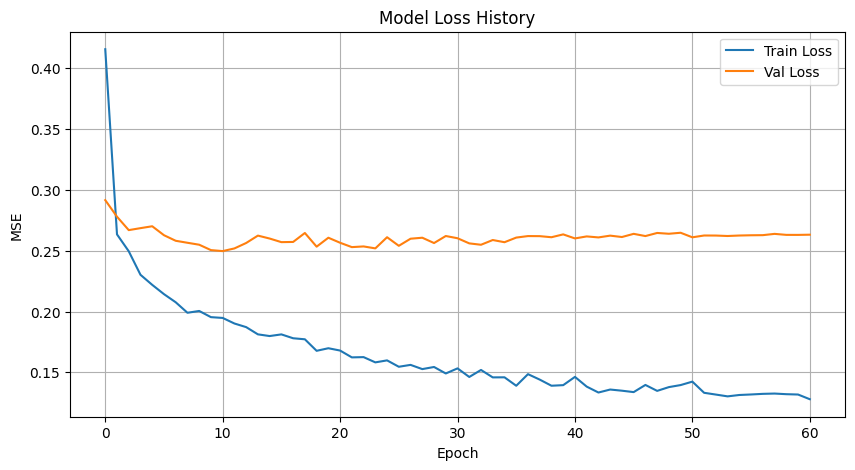

In [35]:
def plot_history(history):
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss History')
    plt.xlabel('Epoch')
    plt.ylabel('MSE')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_history(history)

In [36]:
from sklearn.model_selection import TimeSeriesSplit

# X, y as DataFrames/Series BEFORE scaling (we scale inside each fold to avoid leakage)
X_all = df.drop(columns=[TARGET])
y_all = df[TARGET]

tscv = TimeSeriesSplit(n_splits=5)
rmses, r2s = [], []
for i, (tr, te) in enumerate(tscv.split(X_all), 1):
    sc = StandardScaler()
    Xtr = sc.fit_transform(X_all.iloc[tr])
    Xte = sc.transform(X_all.iloc[te])          # scaler fit on train fold only
    ytr, yte = y_all.iloc[tr], y_all.iloc[te]

    m = HistGradientBoostingRegressor(
        max_iter=600, learning_rate=0.05, max_leaf_nodes=63,
        l2_regularization=1.0, random_state=42,
    )
    m.fit(Xtr, ytr)
    p = m.predict(Xte)
    rm = np.sqrt(mean_squared_error(yte, p)); r = r2_score(yte, p)
    rmses.append(rm); r2s.append(r)
    print(f"fold {i}: RMSE {rm:6.1f}  R2 {r:.3f}")

print(f"\nMEAN: RMSE {np.mean(rmses):.1f} +/- {np.std(rmses):.1f}   R2 {np.mean(r2s):.3f}")


fold 1: RMSE  629.8  R2 0.562
fold 2: RMSE  409.0  R2 0.808
fold 3: RMSE  334.5  R2 0.863
fold 4: RMSE  516.7  R2 0.690
fold 5: RMSE  649.6  R2 0.489

MEAN: RMSE 507.9 +/- 122.4   R2 0.682
